<a href="https://colab.research.google.com/github/Aaaaddddyyyyyyyy/Machine-Learning-repo/blob/main/Bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('/content/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df=df.iloc[:,1:]
df.head()           ## droping id column using iloc function

,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,3.5,1.4,0.2,Iris-setosa
1,3.0,1.4,0.2,Iris-setosa
2,3.2,1.3,0.2,Iris-setosa
3,3.1,1.5,0.2,Iris-setosa
4,3.6,1.4,0.2,Iris-setosa


In [7]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()                               ### converting species into 0 or 1 format using label encoder

In [10]:
df['Species']=lb.fit_transform(df['Species'])  ## converted species into 0 or 1 format
df.head()

,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [13]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

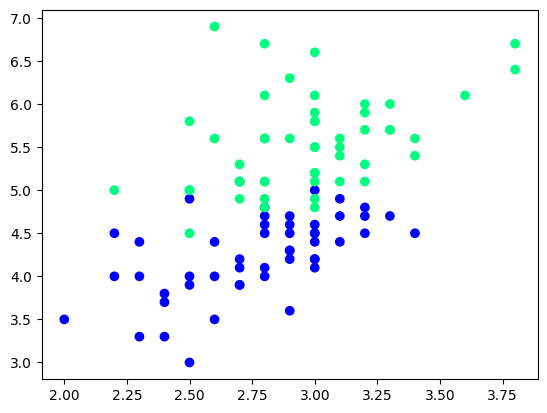

In [15]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [20]:
# traing the model
df.sample(100)
df_train= df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [21]:
df_train

,SepalWidthCm,PetalLengthCm,Species
57,2.4,3.3,1
92,2.6,4.0,1
104,3.0,5.8,2
87,2.3,4.4,1
65,3.1,4.4,1
88,3.0,4.1,1
51,3.2,4.5,1
64,2.9,3.6,1
84,3.0,4.5,1
103,2.9,5.6,2


In [22]:
df_val

,SepalWidthCm,PetalLengthCm,Species
116,3.0,5.5,2
118,2.6,6.9,2
129,3.0,5.8,2
115,3.2,5.3,2
127,3.0,4.9,2


In [23]:
df_test

,SepalWidthCm,PetalLengthCm,Species
149,3.0,5.1,2
143,3.2,5.9,2
134,2.6,5.6,2
147,3.0,5.2,2
142,2.7,5.1,2


In [24]:
X_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,-1].values

In [25]:
X_test

array([[3. , 5.5],
       [2.6, 6.9],
       [3. , 5.8],
       [3.2, 5.3],
       [3. , 4.9]])

In [26]:
y_test

array([2, 2, 2, 2, 2])

BAgging

In [30]:
## data for tree 1
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
65,3.1,4.4,1
57,2.4,3.3,1
103,2.9,5.6,2
87,2.3,4.4,1
103,2.9,5.6,2
65,3.1,4.4,1
51,3.2,4.5,1
65,3.1,4.4,1


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [32]:
dt_bag1=DecisionTreeClassifier()

In [34]:
def evaluate(clf,X,y):
  clf.fit(X,y)
  plot_tree(clf)
  plt.show()
  plot_decision_regions(X.values,y.values,clf=clf,legend=2)
  y_pred=clf.predict(X_test)
  print(accuracy_score(y_test,y_pred))

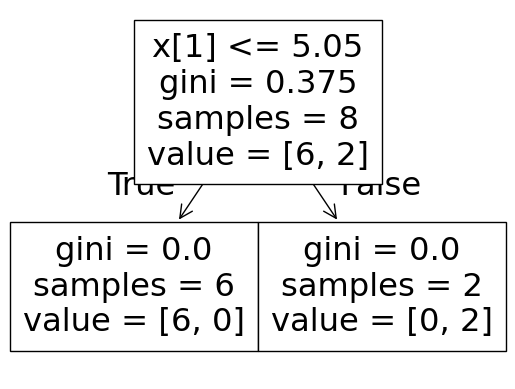

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


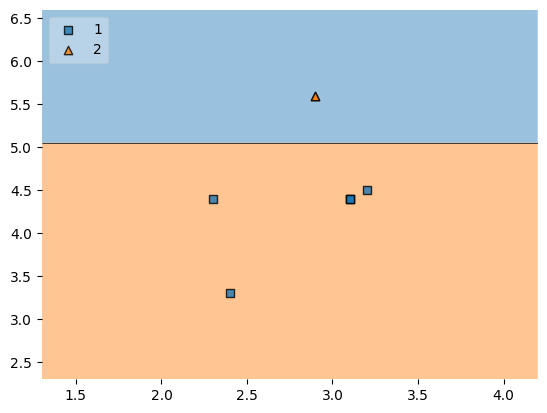

In [35]:
evaluate(dt_bag1,X,y)